In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
""" tiempo_seg = 60    
carga_proton = 1.602177e-19
protones_totales = (corriente_nA * 1e-9 / carga_proton) * tiempo_seg """

In [3]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis_M0.out"

data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 640
Dosis mínima: 0.0055967
Dosis máxima: 0.0081989
Primeros valores: [0.0057551 0.0058427 0.005731  0.0060024 0.0060627 0.0062672 0.0059932
 0.0061663 0.0055967 0.0057741]


In [4]:
print(len(data_dosis))

640


In [5]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [6]:
file_path = "histograma_dosis_M0.out"
mostrar_encabezados_phits(file_path)
data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

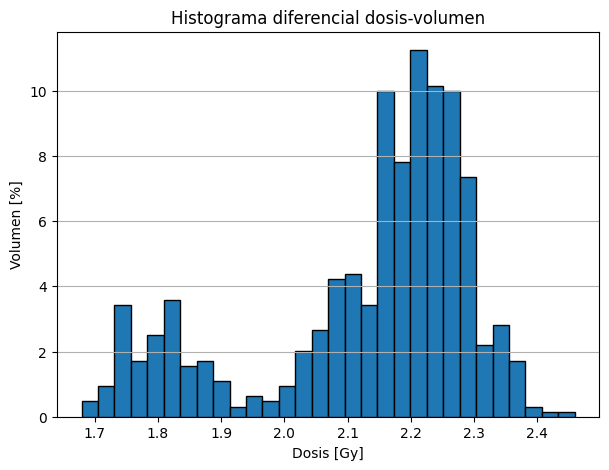

In [7]:
""" tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
) """

tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_voxeles

cantidad_intervalos_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=cantidad_intervalos_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [8]:
# quiero calcular lo que a ojo veo que podria ser aire:

dosis_min_aire_teorico = 1.67
dosis_max_aire_teorico = 1.93

mascara_aire = (data_dosis_fisica >= dosis_min_aire_teorico) & (data_dosis_fisica <= dosis_max_aire_teorico)

n_voxeles_aire = np.sum(mascara_aire)
volumen_aire = 100 * n_voxeles_aire / len(data_dosis_fisica)

print("Cantidad de voxeles en la zona de aire:", n_voxeles_aire)
print("Volumen total de la zona de aire [%]:", volumen_aire)

Cantidad de voxeles en la zona de aire: 110
Volumen total de la zona de aire [%]: 17.1875


In [9]:
# volumen total de la mesh: x= 3.2 * y= 2 * z= 0.2
vol_mesh_total = 3.2*2*0.2
print(f"{vol_mesh_total:.2f} cm^3")

vol_pouch = 1 # (cm^3)

#entonces

vol_aire = vol_mesh_total - vol_pouch
print(f"Volumen de aire: {vol_aire:.2f} cm^3")

porcentaje_pouch = 100 * vol_pouch / vol_mesh_total
porcentaje_aire = 100 * vol_aire / vol_mesh_total

print(f"Porcentaje de pouch: {porcentaje_pouch:.2f}%")
print(f"Porcentaje de aire: {porcentaje_aire:.2f}%")    

1.28 cm^3
Volumen de aire: 0.28 cm^3
Porcentaje de pouch: 78.12%
Porcentaje de aire: 21.88%


In [92]:
# homogeneidad de la dosis en el pouch:

In [10]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)

print(f"Dosis mínima en el pouch: {np.min(data_dosis_fisica):.2f} Gy")
print(f"Dosis máxima en el pouch: {np.max(data_dosis_fisica):.2f} Gy")  
print(f"Dosis media en el pouch: {np.mean(data_dosis_fisica):.2f} Gy")

Dosis mínima en el pouch: 1.68 Gy
Dosis máxima en el pouch: 2.46 Gy
Dosis media en el pouch: 2.13 Gy


In [12]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación de la dosis en el pouch: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Coeficiente de variación de la dosis en el pouch: 8.07%


In [96]:
# histograma dosis-volumen acumulado

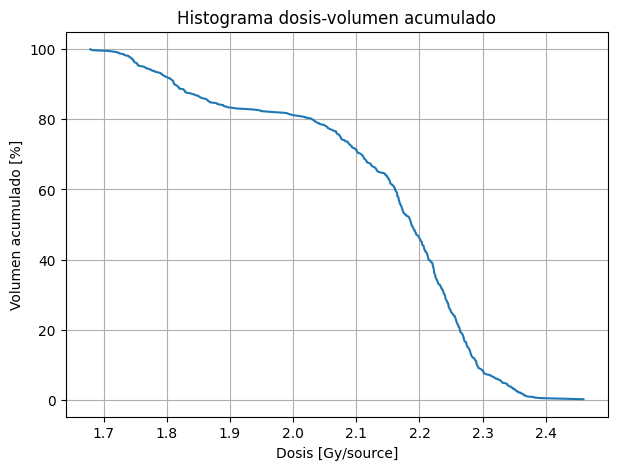

In [128]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)


plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

In [129]:
nx = 10
ny = 16
nz = 4

esperados = nx * ny * nz

print("Valores esperados:", esperados)
print("Valores leídos:", len(data_dosis))

if len(data_dosis) != esperados:
    print("Ojo: no se leyó la cantidad esperada de bins.")
else:
    print("Todo ok: se leyeron todos los bins.")

Valores esperados: 640
Valores leídos: 640
Todo ok: se leyeron todos los bins.


## mascara para sacarle el aire

In [ ]:
# le sacamos el aire

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [14]:
archivo = "histograma_dosis_M0.out"

nx = 10
ny = 16
nz = 4

xmin, xmax = -1.0, 1.0
ymin, ymax = -1.6, 1.6
zmin, zmax = 98.115, 98.315

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

dosis = np.full((nx, ny, nz), np.nan)
err_rel = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosis = float(partes[2])
            valor_err = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosis[ix_actual, iy_actual, contador_z] = valor_dosis
            err_rel[ix_actual, iy_actual, contador_z] = valor_err
            contador_z += 1

In [ ]:
# esta mascara dice: El voxel es pouch si el centro del voxel cae adentro del elipsoide

In [15]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0

zmin_pouch = 98.115
zmax_pouch = 98.315
z0 = 0.5 * (zmin_pouch + zmax_pouch)

rx = 1.0
ry = 1.6
rz = 1.0

mascara_elipsoide = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

mascara_z = (Z >= zmin_pouch) & (Z <= zmax_pouch)

mascara_pouch = mascara_elipsoide & mascara_z

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]

In [16]:
print("z_centros:")
print(z_centros)

print("Máscara pouch en la primera capa z:")
print(mascara_pouch[:, :, 0])

tiempo_seg = 300

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]
data_dosis_fisica = data_dosis * tiempo_seg

print("Cantidad de voxeles dentro del pouch:", len(data_dosis))
print("Dosis mínima dentro del pouch [Gy/source]:", np.min(data_dosis))
print("Dosis máxima dentro del pouch [Gy/source]:", np.max(data_dosis))
print("Dosis mínima dentro del pouch [Gy]:", np.min(data_dosis_fisica))
print("Dosis máxima dentro del pouch [Gy]:", np.max(data_dosis_fisica))
print("Dosis media dentro del pouch [Gy]:", np.mean(data_dosis_fisica))

datos = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datos.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosis[ix, iy, iz],
                    dosis[ix, iy, iz] * tiempo_seg,
                    err_rel[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datos,
    columns=[
        "ix", "iy", "iz",
        "x", "y", "z",
        "dosis_Gy_source",
        "dosis_Gy",
        "err_rel"
    ]
)

df_pouch.head()

z_centros:
[98.14 98.19 98.24 98.29]
Máscara pouch en la primera capa z:
[[False False False False False  True  True  True  True  True  True False
  False False False False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True False False]
 [False  True  True  True  True  True  True  True  True  True  True  True
   True  True  True False]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True]
 [False  True  True  True  True  True  True  True  True  True  True  True
   True  True  True False]
 [False False  True  True  True  True  True  True  True  True  True  True
   True  True False False]
 [False False Fals

,ix,iy,iz,x,y,z,dosis_Gy_source,dosis_Gy,err_rel
0,1,6,1,-0.9,-0.5,98.14,0.007177,2.15298,0.0242
1,1,6,2,-0.9,-0.5,98.19,0.007216,2.16474,0.0243
2,1,6,3,-0.9,-0.5,98.24,0.007246,2.17386,0.0260
3,1,6,4,-0.9,-0.5,98.29,0.006971,2.09127,0.0293
4,1,7,1,-0.9,-0.3,98.14,0.007483,2.24502,0.0233


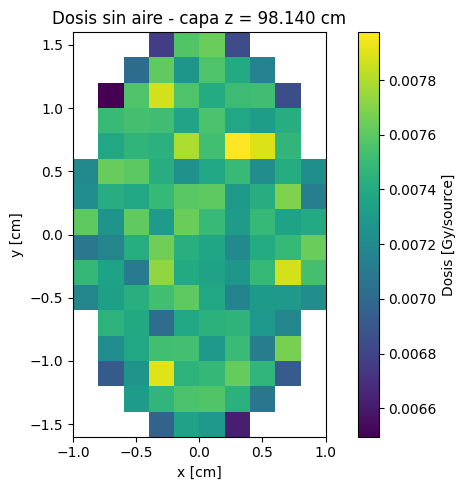

In [17]:
iz = 0

plt.figure(figsize=(7, 5))

plt.imshow(
    dosis_sin_aire[:, :, iz].T,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="equal"
)

plt.colorbar(label="Dosis [Gy/source]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title(f"Dosis sin aire - capa z = {z_centros[iz]:.3f} cm")
plt.tight_layout()
plt.show()

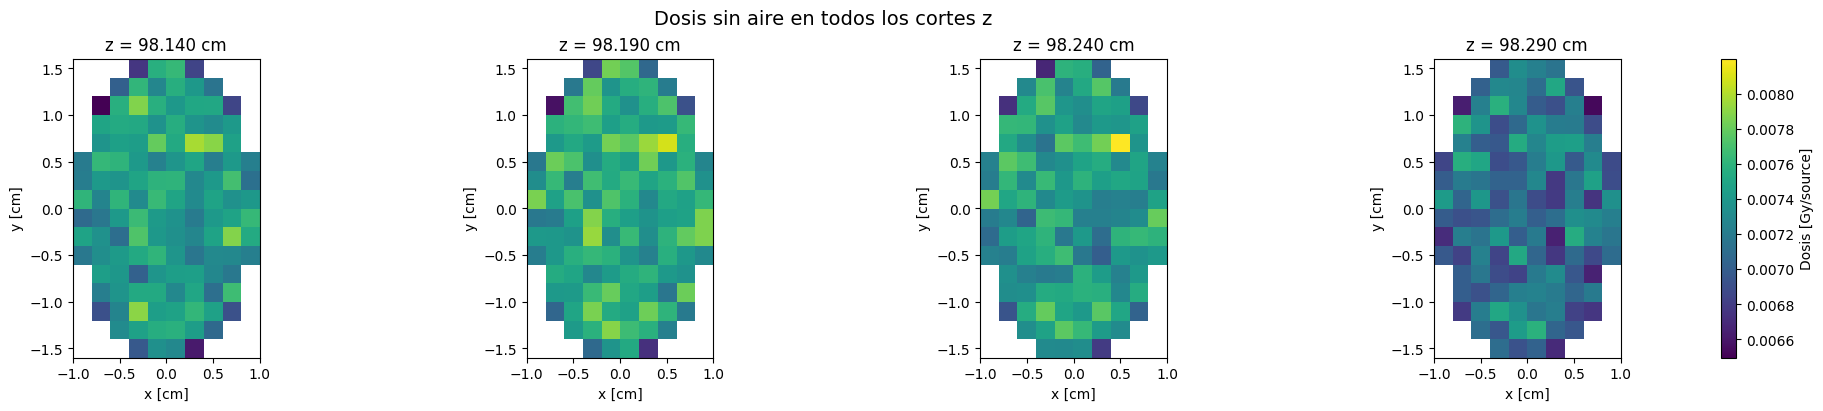

In [18]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_aire)
vmax = np.nanmax(dosis_sin_aire)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_aire[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin aire en todos los cortes z", fontsize=14)
plt.show()

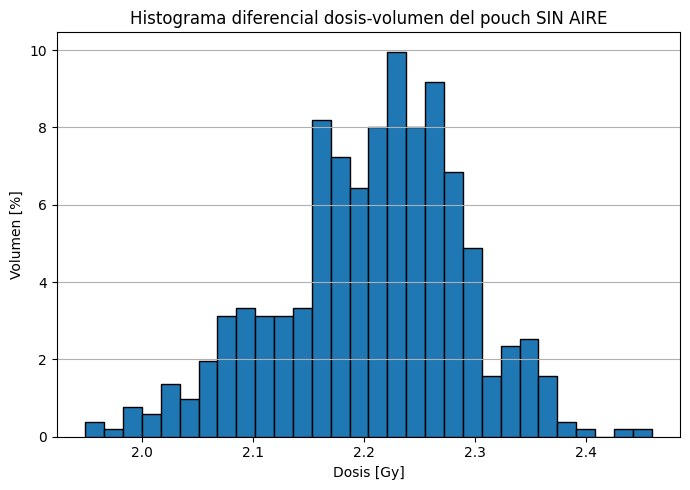

In [20]:
n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay voxeles dentro del pouch. Revisá la máscara y los límites de z.")

volumen_por_voxel = 100.0 / n_voxeles

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))

plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch SIN AIRE")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [21]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)
print(f"Dosis mínima en el pouch: {np.min(data_dosis_fisica):.2f} Gy")
print(f"Dosis máxima en el pouch: {np.max(data_dosis_fisica):.2f} Gy")
print(f"Dosis media en el pouch: {np.mean(data_dosis_fisica):.2f} Gy")

Dosis mínima en el pouch: 1.95 Gy
Dosis máxima en el pouch: 2.46 Gy
Dosis media en el pouch: 2.21 Gy


In [22]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación de la dosis en el pouch: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Coeficiente de variación de la dosis en el pouch: 3.78%


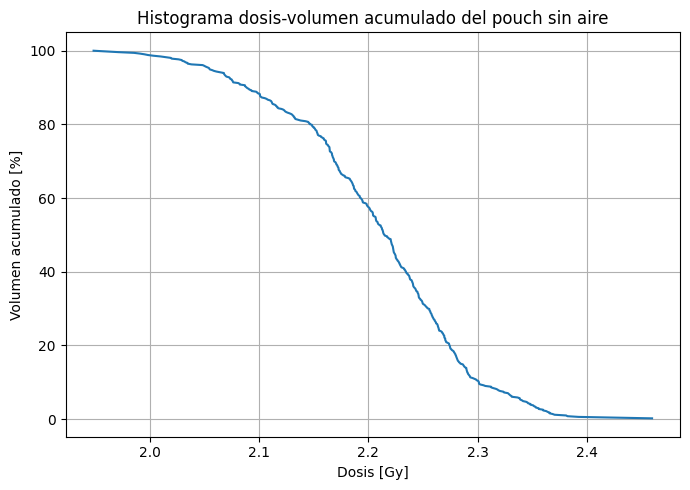

In [23]:
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo o la máscara del pouch.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis_fisica) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis_fisica)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis_fisica >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))

plt.plot(dosis_ordenada, vol_acumulado)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado del pouch sin aire")
plt.grid(True)
plt.tight_layout()
plt.show()

## Cálculo del volumen del pouch cortado




El pouch se modeló en PHITS como un elipsoide:

`100 ell 0.0 0.0 61.01  1.6 0.0 0.0  -1.0`

y fue recortado por los planos:

`201 pz 60.58`

`202 pz 60.78`

Interpretamos entonces un elipsoide centrado en:

$$
z_0 = 61.01 \ \mathrm{cm}
$$

con semiejes:

$$
a_x = 1.6 \ \mathrm{cm}
$$

$$
a_y = 1.0 \ \mathrm{cm}
$$

$$
a_z = 1.0 \ \mathrm{cm}
$$

La ecuación del elipsoide es:

$$
\frac{x^2}{a_x^2}
+
\frac{y^2}{a_y^2}
+
\frac{(z-z_0)^2}{a_z^2}
\leq 1
$$

es decir:

$$
\frac{x^2}{1.6^2}
+
\frac{y^2}{1.0^2}
+
\frac{(z-61.01)^2}{1.0^2}
\leq 1
$$

Los planos de corte limitan el volumen entre:

$$
z_1 = 60.58 \ \mathrm{cm}
$$

$$
z_2 = 60.78 \ \mathrm{cm}
$$

Para un valor fijo de $z$, la sección transversal del elipsoide es una elipse. Su área depende de qué tan lejos estemos del centro del elipsoide.

La ecuación del elipsoide se puede escribir como:

$$
\frac{x^2}{a_x^2}
+
\frac{y^2}{a_y^2}
\leq
1-
\frac{(z-z_0)^2}{a_z^2}
$$

Entonces, a cada altura $z$, los semiejes de la sección elíptica quedan reducidos por el factor:

$$
\sqrt{
1-
\frac{(z-z_0)^2}{a_z^2}
}
$$

Por lo tanto, el área de la sección transversal es:

$$
A(z)
=
\pi a_x a_y
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
$$

El volumen del pouch cortado se calcula integrando esa área entre los planos de corte:

$$
V
=
\int_{z_1}^{z_2}
A(z)\,dz
$$

Reemplazando $A(z)$:

$$
V
=
\int_{z_1}^{z_2}
\pi a_x a_y
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
dz
$$

Sacando las constantes fuera de la integral:

$$
V
=
\pi a_x a_y
\int_{z_1}^{z_2}
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
dz
$$

La integral es:

$$
V
=
\pi a_x a_y
\left[
(z-z_0)
-
\frac{(z-z_0)^3}{3a_z^2}
\right]_{z_1}^{z_2}
$$

Reemplazando los valores:

$$
V
=
\pi (1.6)(1.0)
\left[
(z-61.01)
-
\frac{(z-61.01)^3}{3(1.0)^2}
\right]_{60.58}^{60.78}
$$

Definimos:

$$
u = z-z_0
$$

Entonces:

$$
u_1 = z_1-z_0
$$

$$
u_1 = 60.58-61.01
$$

$$
u_1 = -0.43 \ \mathrm{cm}
$$

y:

$$
u_2 = z_2-z_0
$$

$$
u_2 = 60.78-61.01
$$

$$
u_2 = -0.23 \ \mathrm{cm}
$$

Entonces el volumen queda:

$$
V
=
\pi (1.6)(1.0)
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
$$

Evaluamos en el extremo superior:

$$
u_2-\frac{u_2^3}{3}
=
-0.23-\frac{(-0.23)^3}{3}
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.23-\frac{-0.012167}{3}
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.23+0.004056
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.225944
$$

Evaluamos en el extremo inferior:

$$
u_1-\frac{u_1^3}{3}
=
-0.43-\frac{(-0.43)^3}{3}
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.43-\frac{-0.079507}{3}
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.43+0.026502
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.403498
$$

Restamos ambos valores:

$$
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
=
-0.225944 - (-0.403498)
$$

$$
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
=
0.177554
$$

Entonces:

$$
V
=
\pi (1.6)(1.0)(0.177554)
$$

$$
V
=
0.8925 \ \mathrm{cm^3}
$$

Por lo tanto, el volumen aproximado del pouch cortado es:

$$
\boxed{
V_{\mathrm{pouch}} \approx 0.89 \ \mathrm{cm^3}
}
$$